

Selecione uma opção:
1. Executar o pipeline de treinamento
2. Executar o pipeline de teste
3. Sair





Found 1200 images belonging to 4 classes.
Found 200 images belonging to 4 classes.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 7, 1280)     │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,345,348 (8.95 MB)

 Trainable params: 84,804 (331.27 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 310ms/step - accuracy: 0.3650 - loss: 1.4542 - val_accuracy: 0.6700 - val_loss: 1.1218 - learning_rate: 1.0000e-04
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 293ms/step - accuracy: 0.5883 - loss: 1.1124 - val_accuracy: 0.8900 - val_loss: 0.8466 - learning_rate: 1.0000e-04
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 295ms/step - accuracy: 0.7283 - loss: 0.8994 - val_accuracy: 0.9300 - val_loss: 0.6781 - learning_rate: 1.0000e-04
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 281ms/step - accuracy: 0.7900 - loss: 0.7614 - val_accuracy: 0.9450 - val_loss: 0.5644 - learning_rate: 1.0000e-04
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 305ms/step - accuracy: 0.8275 - loss: 0.6786 - val_accuracy: 0.9550 - val_loss: 0.4864 - learning_rate: 1.0000e-04
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 295ms/step - accuracy: 0.8575 - loss: 0.5889 - val_accuracy: 0.9600 - val_loss: 0.4297 - learning_rate: 1.0000e-04
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 287ms/step - acc

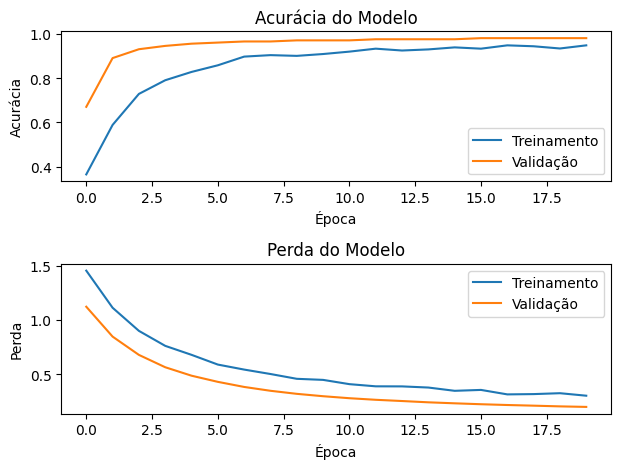



Selecione uma opção:
1. Executar o pipeline de treinamento
2. Executar o pipeline de teste
3. Sair





Found 200 images belonging to 4 classes.
7/7 - 3s - 389ms/step

Matriz salva na pasta: ./resultados/



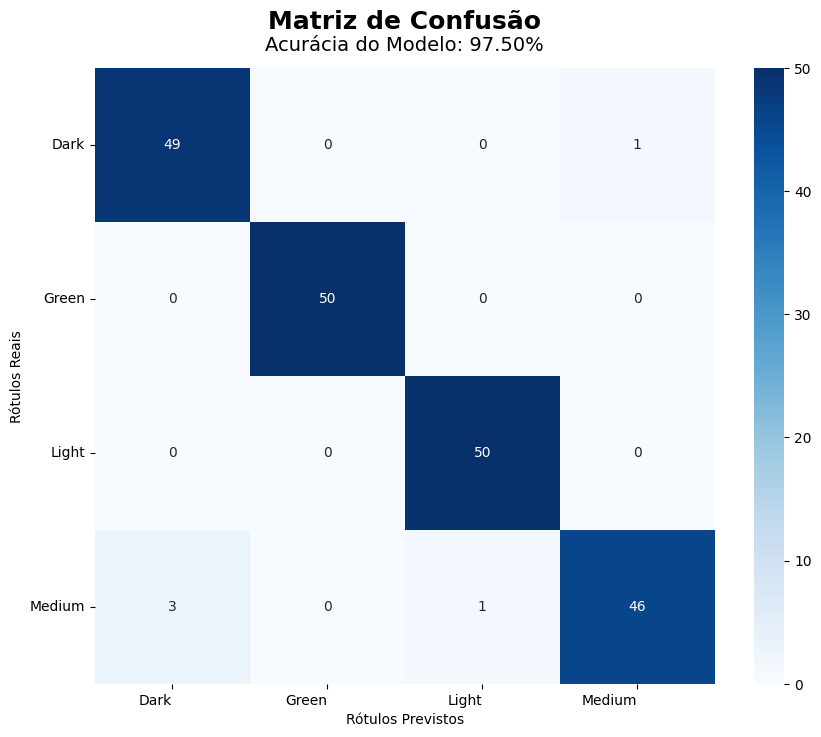


Métrica salva na pasta: ./resultados/



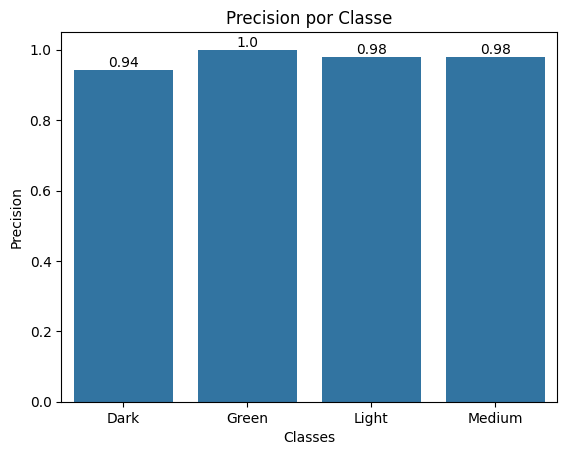


Métrica salva na pasta: ./resultados/



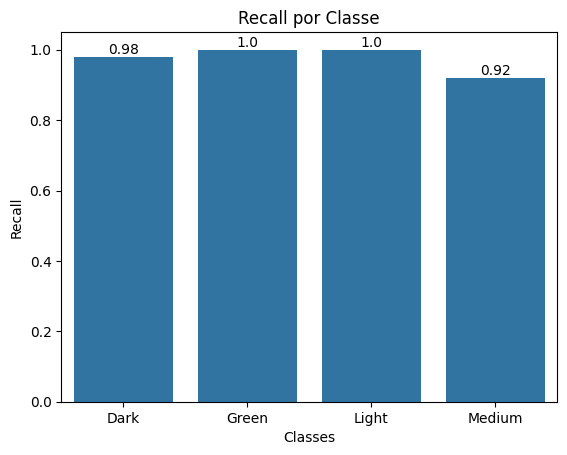


Métrica salva na pasta: ./resultados/



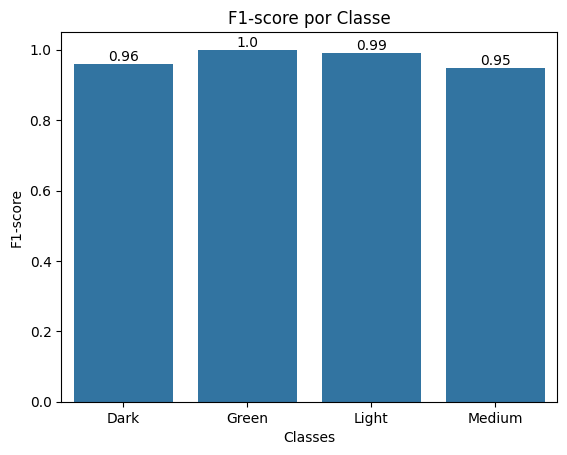



Selecione uma opção:
1. Executar o pipeline de treinamento
2. Executar o pipeline de teste
3. Sair


Execução finalizada!


In [1]:
# @title
import ipywidgets as widgets
from IPython.display import display, HTML, Javascript
from sklearn import preprocessing
import numpy as np
import sys
import warnings
warnings.filterwarnings("ignore", message="Your PyDataset")
warnings.filterwarnings('ignore', category=UserWarning, module='tensorflow')
warnings.filterwarnings("ignore")
import tensorflow as tf
import os
import logging
# Define o nível de log da Tensorflow para 3 e ignora os demais níveis
logging.disable(logging.WARNING)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0 (INFO), 1 (WARNING), 2 (ERROR), 3 (FATAL)

from modulos.classificadores import cnn_teste as modulo_cnn_teste, cnn_treino as modulo_cnn_treino

########################################################################
# CAMINHOS E VARIAVES GLOBAIS
########################################################################

caminho_base = '.'
caminho_todos_datasets = caminho_base + '/datasets/'
selected_dataset = 'coffee_bean'
caminho_imagens_treino = caminho_todos_datasets + selected_dataset + '/train/'
caminho_imagens_val = caminho_todos_datasets + selected_dataset + '/val/'
caminho_imagens_teste = caminho_todos_datasets + selected_dataset + '/test/'
caminho_log = caminho_base + '/log/logger.csv'
caminho_checkpoints = caminho_base + '/checkpoints/cp.weights.h5'
caminho_modelo_cnn_treinado = caminho_base + '/modelos/my_mobile_net_v2.keras'
caminho_resultados = caminho_base + '/resultados/'
forma_img = (224,224,3)
metrica = 'accuracy'
tam_lote = 32
num_epocas = 20

########################################################################
# FUNÇÕES DE EXECUÇÃO DOS PIPELINES
########################################################################

def pipeline_treinamento():
    print("\n\n")
    ########################################################################
    # OBTEM AS IMAGENS DE TREINAMENTO E VALIDACAO
    ########################################################################

    imagens_treino = modulo_cnn_treino.obter_imagens_treino(
        caminho_imagens_treino,
        forma_img,
        tam_lote)
    imagens_validacao = modulo_cnn_treino.obter_imagens_validacao(
        caminho_imagens_val,
        forma_img,
        tam_lote)
    num_classes = imagens_treino.num_classes

    ########################################################################
    # OBTEM E COMPILA O MODELO
    ########################################################################

    modelo_cnn = modulo_cnn_treino.obter_modelo_cnn(num_classes)
    modelo_compilado = modulo_cnn_treino.compilar_modelo_cnn(modelo_cnn, metrica)

    ########################################################################
    # OBTEM A LISTA DE CALLBACKS
    ########################################################################

    cp = modulo_cnn_treino.obter_checkpoint_callback(caminho_checkpoints)
    log = modulo_cnn_treino.obter_log_callback(caminho_log)
    lr = modulo_cnn_treino.obter_reduce_lr_callback()
    es = modulo_cnn_treino.obter_early_stop_callback()
    lista_callbacks = [cp, log, lr, es]

    ########################################################################
    # TREINA O MODELO
    ########################################################################

    modelo_treinado, historico = modulo_cnn_treino.treinar_modelo(modelo_compilado, imagens_treino, imagens_validacao, num_epocas, caminho_checkpoints,lista_callbacks)

    ########################################################################
    # SALVA MODELO
    ########################################################################

    modulo_cnn_treino.salvar_modelo(modelo_treinado, caminho_modelo_cnn_treinado)

    ########################################################################
    # PLOTA E SALVA HISTÓRICO DO TREINAMENTO
    ########################################################################

    modulo_cnn_treino.plot_historico(historico,metrica,caminho_resultados)


def pipeline_teste():
    print("\n\n")
    ########################################################################
    # OBTEM AS IMAGENS E OS ROTULOS DE TESTE
    ########################################################################

    imagens_teste = modulo_cnn_teste.obter_imagens_teste(
        caminho_imagens_teste,
        forma_img,
        tam_lote)
    rotulos_verdadeiros = imagens_teste.classes
    nomes_das_classes = list(imagens_teste.class_indices.keys())

    ########################################################################
    # CARREGA O MODELO TREINADO A PARTIR DE UM ARQUIVO
    ########################################################################

    modelo_treinado = modulo_cnn_teste.carregar_modelo_cnn_treinado(
        caminho_modelo_cnn_treinado)

    ########################################################################
    # TESTA O MODELO
    ########################################################################

    rotulos_previstos = modulo_cnn_teste.testar_modelo(modelo_treinado, imagens_teste)

    ########################################################################
    # PLOTA E SALVA RESULTADOS DO MODELO
    ########################################################################

    modulo_cnn_teste.matriz_confusao(
        rotulos_verdadeiros,
        rotulos_previstos,
        nomes_das_classes,
        caminho_resultados)

    modulo_cnn_teste.plot_metrica(
        rotulos_verdadeiros,
        rotulos_previstos,
        'precision',
        nomes_das_classes,
        caminho_resultados)

    modulo_cnn_teste.plot_metrica(
        rotulos_verdadeiros,
        rotulos_previstos,
        'recall',
        nomes_das_classes,
        caminho_resultados)

    modulo_cnn_teste.plot_metrica(
        rotulos_verdadeiros,
        rotulos_previstos,
        'f1-score',
        nomes_das_classes,
        caminho_resultados)

########################################################################
# MENU PARA ESCOLHA DOS PIPELINES
 ########################################################################

def menu():
    while True:
        print("\n")
        print("Selecione uma opção:")
        print("1. Executar o pipeline de treinamento")
        print("2. Executar o pipeline de teste")
        print("3. Sair")
        print("\n")

        escolha = input("Digite o número da sua escolha: ")

        if escolha == '1':
            pipeline_treinamento()
        elif escolha == '2':
            pipeline_teste()
        elif escolha == '3':
            print("Execução finalizada!")
            break
        else:
            print("Escolha inválida. Por favor, selecione uma opção válida.")

# Chamada do menu para que o usuário faça a escolha
menu()


################ FIM DO SCRIPT ########################
